# 06 — Twitch Ranking Evaluation v5

This version avoids the unreliable `baseline_predictions.csv.gz` completely.

Instead it:

1. loads the **saved Logistic Regression model** from Notebook 03;
2. loads the **saved HistGradientBoosting model** from Notebook 03;
3. loads the **Neural MLP predictions** from Notebook 04;
4. selects the exact same `(user_id, streamer)` rows from the prepared test table;
5. recomputes Logistic, HGB, and popularity scores on those rows;
6. compares all rankers fairly.

This removes the `score_logreg` file-column problem entirely.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# ---------------------------------------------------------------------
# Locate the real project root
# ---------------------------------------------------------------------
HOME_PROJECT = (
    Path.home()
    / "Desktop"
    / "resume_projects"
    / "Distributed ML Inference & Ranking"
)

cwd = Path.cwd()

PROJECT_CANDIDATES = [
    HOME_PROJECT,
    cwd,
    *cwd.parents,
]

PROJECT_DIR = next(
    (
        p for p in PROJECT_CANDIDATES
        if (
            (p / "data/processed/twitch/twitch_test_ranking.csv.gz").exists()
            or (p / "data/raw/twitch/100k_a.csv").exists()
        )
    ),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Set PROJECT_DIR manually in this cell."
    )

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "06_twitch_ranking_evaluation"
)

ARTIFACT_DIR = (
    PROJECT_DIR
    / "artifacts"
    / "twitch"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_DIR)

print("\nResults:")
print(RESULTS_DIR)


Project root:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking

Results:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/06_twitch_ranking_evaluation


## 1. Find the required files anywhere inside the project

Earlier notebooks sometimes created a nested project directory under `notebooks/`, so this notebook searches recursively.


In [2]:
def find_file(
    filenames,
    required=True,
    prefer_terms=(),
):
    if isinstance(filenames, str):
        filenames = [filenames]

    matches = []

    for filename in filenames:
        matches.extend(
            PROJECT_DIR.rglob(filename)
        )

    matches = list(dict.fromkeys(matches))

    if not matches:
        if required:
            raise FileNotFoundError(
                "Could not find: "
                + ", ".join(filenames)
            )
        return None

    def rank(path):
        text = str(path).lower()

        preference = sum(
            term.lower() in text
            for term in prefer_terms
        )

        # Prefer paths with desired terms, then shorter canonical paths.
        return (
            -preference,
            len(path.parts),
            len(str(path)),
        )

    return sorted(matches, key=rank)[0]


TEST_PATH = find_file(
    "twitch_test_ranking.csv.gz",
    prefer_terms=("data/processed/twitch",),
)

LOGREG_PATH = find_file(
    "baseline_logistic_regression.joblib",
    prefer_terms=("artifacts/twitch",),
)

HGB_PATH = find_file(
    "baseline_hist_gradient_boosting.joblib",
    prefer_terms=("artifacts/twitch",),
)

NEURAL_PRED_PATH = find_file(
    [
        "neural_predictions_mac_subset.csv.gz",
        "neural_predictions.csv.gz",
    ],
    prefer_terms=("predictions",),
)

CANDIDATE_SUMMARY_PATH = find_file(
    "candidate_summary_v2.csv",
    required=False,
    prefer_terms=("05_twitch_candidate_generation",),
)

CANDIDATE_SOURCE_PATH = find_file(
    "candidate_source_summary_v2.csv",
    required=False,
    prefer_terms=("05_twitch_candidate_generation",),
)

CANDIDATE_FEATURE_PATH = find_file(
    [
        "twitch_candidate_base_features.csv.gz",
        "twitch_generated_candidates_v2.csv.gz",
    ],
    required=False,
    prefer_terms=("data/processed/twitch",),
)

print("Prepared test table:")
print(TEST_PATH)

print("\nLogistic model:")
print(LOGREG_PATH)

print("\nHGB model:")
print(HGB_PATH)

print("\nNeural predictions:")
print(NEURAL_PRED_PATH)

print("\nCandidate summary:")
print(CANDIDATE_SUMMARY_PATH)

print("\nCandidate v2 feature table:")
print(CANDIDATE_FEATURE_PATH)


Prepared test table:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/data/processed/twitch/twitch_test_ranking.csv.gz

Logistic model:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/baseline_logistic_regression.joblib

HGB model:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/baseline_hist_gradient_boosting.joblib

Neural predictions:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking/data/processed/twitch/predictions/neural_predictions_mac_subset.csv.gz

Candidate summary:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/05_twitch_candidate_generation/candidate_summary_v2.csv

Candidate v2 feature table:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/data/processed/twitch/twitch_candidate_base_features.csv.gz


## 2. Load the exact 36-feature test table and neural predictions

We use the neural prediction rows as the fair comparison population because Notebook 04 intentionally evaluated a CPU-friendly subset.

Then Logistic Regression and HGB are re-scored on those **same rows**.


In [3]:
test = pd.read_csv(TEST_PATH)
neural = pd.read_csv(NEURAL_PRED_PATH)

print("Prepared test shape:", test.shape)
print("Neural prediction shape:", neural.shape)

print("\nNeural columns:")
print(neural.columns.tolist())

# Normalize the neural score column if an older notebook used another name.
if "score_neural" not in neural.columns:
    aliases = [
        "neural_score",
        "score_mlp",
        "mlp_score",
        "prediction",
        "predicted_probability",
        "probability",
    ]

    found = next(
        (c for c in aliases if c in neural.columns),
        None,
    )

    if found is None:
        raise ValueError(
            "Could not find a neural prediction score column. "
            f"Columns found: {neural.columns.tolist()}"
        )

    neural = neural.rename(
        columns={found: "score_neural"}
    )

    print(
        f"Renamed {found!r} -> 'score_neural'"
    )

required_neural = {
    "user_id",
    "streamer",
    "score_neural",
}

missing = required_neural - set(neural.columns)

if missing:
    raise ValueError(
        f"Neural prediction file is missing: {sorted(missing)}"
    )

neural_keys = (
    neural[
        ["user_id", "streamer", "score_neural"]
    ]
    .drop_duplicates(
        ["user_id", "streamer"]
    )
)

fair = test.merge(
    neural_keys,
    on=["user_id", "streamer"],
    how="inner",
    validate="one_to_one",
)

print("\nFair-comparison rows:", f"{len(fair):,}")
print("Fair-comparison users:", f"{fair['user_id'].nunique():,}")
print("Positive rate:", round(float(fair["label"].mean()), 6))


Prepared test shape: (240605, 41)
Neural prediction shape: (118750, 5)

Neural columns:
['user_id', 'streamer', 'label', 'seen_before', 'score_neural']

Fair-comparison rows: 118,750
Fair-comparison users: 5,000
Positive rate: 0.2


## 3. Load Notebook 03 models and reconstruct scores

This is the key fix.

We do **not** read `score_logreg` or `score_hgb` from an old prediction CSV.


In [4]:
logreg = joblib.load(LOGREG_PATH)
hgb_bundle = joblib.load(HGB_PATH)

if not isinstance(hgb_bundle, dict):
    raise TypeError(
        "Expected the HGB artifact to be a dictionary "
        "containing model, imputer, and feature_columns."
    )

hgb = hgb_bundle["model"]
hgb_imputer = hgb_bundle["imputer"]
FEATURE_COLUMNS = list(
    hgb_bundle["feature_columns"]
)

print("Ranking features:", len(FEATURE_COLUMNS))

missing_features = [
    c for c in FEATURE_COLUMNS
    if c not in fair.columns
]

if missing_features:
    raise ValueError(
        "Prepared test table is missing model features: "
        f"{missing_features}"
    )

X_fair = fair[FEATURE_COLUMNS]

# ------------------------------------------------------------
# Popularity baseline — same definition as Notebook 03
# ------------------------------------------------------------
fair["score_popularity"] = (
    fair["streamer_interactions"]
    .fillna(0)
)

# ------------------------------------------------------------
# Logistic Regression pipeline
# Includes its own median imputer + StandardScaler.
# ------------------------------------------------------------
fair["score_logreg"] = (
    logreg.predict_proba(
        X_fair
    )[:, 1]
)

# ------------------------------------------------------------
# HistGradientBoosting
# Notebook 03 used a separate median imputer.
# ------------------------------------------------------------
X_hgb = hgb_imputer.transform(
    X_fair
)

fair["score_hgb"] = (
    hgb.predict_proba(
        X_hgb
    )[:, 1]
)

print("Recomputed:")
print("- score_popularity")
print("- score_logreg")
print("- score_hgb")

print("\nNeural score already present:")
print("- score_neural")

display(
    fair[
        [
            "user_id",
            "streamer",
            "label",
            "score_popularity",
            "score_logreg",
            "score_hgb",
            "score_neural",
        ]
    ].head()
)


Ranking features: 36
Recomputed:
- score_popularity
- score_logreg
- score_hgb

Neural score already present:
- score_neural


,user_id,streamer,label,score_popularity,score_logreg,score_hgb,score_neural
0,30,a881881,1,5.0,0.993464,0.999478,0.989781
1,30,arang_1009,1,0.0,0.054845,0.991780,0.053788
2,30,mlb417,1,2.0,0.039361,0.999691,0.054309
3,30,nunseol0323,1,0.0,0.054845,0.991780,0.053788
4,30,thymine0614,1,2.0,0.998212,0.999813,0.997600


## 4. Classification sanity check

Before ranking metrics, verify that reconstructed scores are sensible.


In [5]:
classification_rows = []

for name, score_col in [
    ("Popularity", "score_popularity"),
    ("Logistic Regression", "score_logreg"),
    ("HistGradientBoosting", "score_hgb"),
    ("Neural MLP", "score_neural"),
]:
    classification_rows.append(
        {
            "model": name,
            "ROC_AUC": roc_auc_score(
                fair["label"],
                fair[score_col],
            ),
            "AveragePrecision": average_precision_score(
                fair["label"],
                fair[score_col],
            ),
        }
    )

classification_comparison = pd.DataFrame(
    classification_rows
)

display(
    classification_comparison.round(6)
)


,model,ROC_AUC,AveragePrecision
0,Popularity,0.810070,0.718150
1,Logistic Regression,0.916525,0.861360
2,HistGradientBoosting,0.963284,0.926244
3,Neural MLP,0.920538,0.864168


## 5. Ranking metric functions


In [6]:
def evaluate_ranker(
    frame,
    score_col,
    ks=(5, 10, 20),
):
    ranked = frame.sort_values(
        ["user_id", score_col],
        ascending=[True, False],
        kind="stable",
    )

    user_rows = []

    for user_id, group in ranked.groupby(
        "user_id",
        sort=False,
    ):
        labels = group[
            "label"
        ].to_numpy(
            dtype=np.int8
        )

        positives = int(
            labels.sum()
        )

        if positives == 0:
            continue

        positive_positions = np.flatnonzero(
            labels == 1
        )

        row = {
            "user_id": user_id,
            "MRR": (
                1.0
                / (
                    positive_positions[0]
                    + 1
                )
            ),
        }

        for k in ks:
            top = labels[:k]
            hits = int(top.sum())

            row[f"Recall@{k}"] = (
                hits / positives
            )

            row[f"HitRate@{k}"] = float(
                hits > 0
            )

            discounts = (
                1.0
                / np.log2(
                    np.arange(
                        2,
                        len(top) + 2,
                    )
                )
            )

            dcg = float(
                (top * discounts).sum()
            )

            ideal_len = min(
                positives,
                k,
            )

            ideal_dcg = float(
                (
                    1.0
                    / np.log2(
                        np.arange(
                            2,
                            ideal_len + 2,
                        )
                    )
                ).sum()
            )

            row[f"NDCG@{k}"] = (
                dcg / ideal_dcg
                if ideal_dcg > 0
                else np.nan
            )

        user_rows.append(row)

    per_user = pd.DataFrame(
        user_rows
    )

    summary = {
        "MRR": per_user["MRR"].mean(),
    }

    for k in ks:
        summary[f"Recall@{k}"] = (
            per_user[f"Recall@{k}"].mean()
        )

        summary[f"HitRate@{k}"] = (
            per_user[f"HitRate@{k}"].mean()
        )

        summary[f"NDCG@{k}"] = (
            per_user[f"NDCG@{k}"].mean()
        )

    return summary, per_user


## 6. Fair ranking comparison


In [7]:
MODEL_SCORES = {
    "Popularity": "score_popularity",
    "Logistic Regression": "score_logreg",
    "HistGradientBoosting": "score_hgb",
    "Neural MLP": "score_neural",
}

summary_rows = []
per_user_results = {}

for model_name, score_col in MODEL_SCORES.items():
    ranking_summary, per_user = evaluate_ranker(
        fair,
        score_col,
    )

    row = {
        "model": model_name,
        "ROC_AUC": roc_auc_score(
            fair["label"],
            fair[score_col],
        ),
        "AveragePrecision": average_precision_score(
            fair["label"],
            fair[score_col],
        ),
        **ranking_summary,
    }

    summary_rows.append(row)
    per_user_results[model_name] = per_user

comparison = (
    pd.DataFrame(summary_rows)
    .sort_values(
        "NDCG@10",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison.round(6)
)


,model,ROC_AUC,AveragePrecision,MRR,Recall@5,HitRate@5,NDCG@5,Recall@10,HitRate@10,NDCG@10,Recall@20,HitRate@20,NDCG@20
0,HistGradientBoosting,0.963284,0.926244,0.986550,0.836962,1.0000,0.960770,0.940478,1.0000,0.961578,0.982871,1.000,0.966200
1,Neural MLP,0.920538,0.864168,0.959652,0.796366,0.9936,0.912669,0.909004,0.9994,0.915121,0.963720,1.000,0.924068
2,Logistic Regression,0.916525,0.861360,0.959505,0.796566,0.9940,0.912475,0.908656,0.9994,0.914859,0.962746,1.000,0.923365
3,Popularity,0.810070,0.718150,0.879217,0.742508,0.9758,0.811184,0.862114,0.9930,0.823729,0.935653,0.999,0.844260


## 7. Core ranking plots


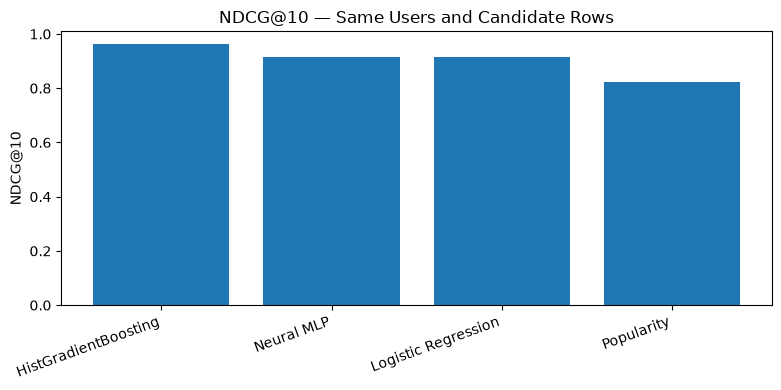

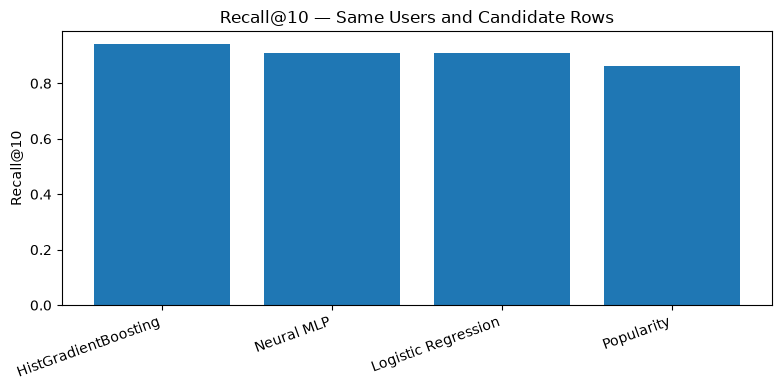

In [8]:
for metric in [
    "NDCG@10",
    "Recall@10",
]:
    plt.figure(
        figsize=(8, 4)
    )

    plt.bar(
        comparison["model"],
        comparison[metric],
    )

    plt.ylabel(metric)
    plt.title(
        f"{metric} — Same Users and Candidate Rows"
    )

    plt.xticks(
        rotation=20,
        ha="right",
    )

    plt.tight_layout()

    path = (
        RESULTS_DIR
        / f"{metric.lower().replace('@', '_at_')}.png"
    )

    plt.savefig(
        path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


## 8. Repeat vs new-streamer positives


In [9]:
positive_rows = fair[
    fair["label"].eq(1)
].copy()

positive_rows[
    "positive_type"
] = np.where(
    positive_rows[
        "seen_before"
    ].fillna(0).eq(1),
    "Repeat streamer",
    "New streamer",
)

positive_type_counts = (
    positive_rows[
        "positive_type"
    ]
    .value_counts()
    .rename_axis(
        "positive_type"
    )
    .reset_index(
        name="positive_rows"
    )
)

positive_type_counts[
    "share"
] = (
    positive_type_counts[
        "positive_rows"
    ]
    / positive_type_counts[
        "positive_rows"
    ].sum()
)

display(
    positive_type_counts
)


,positive_type,positive_rows,share
0,Repeat streamer,13092,0.551242
1,New streamer,10658,0.448758


## 9. Model scores on repeat vs new positive rows


In [10]:
segment_rows = []

for model_name, score_col in MODEL_SCORES.items():
    for segment, group in positive_rows.groupby(
        "positive_type"
    ):
        segment_rows.append(
            {
                "model": model_name,
                "segment": segment,
                "mean_score": group[
                    score_col
                ].mean(),
                "median_score": group[
                    score_col
                ].median(),
                "positive_rows": len(group),
            }
        )

segment_scores = pd.DataFrame(
    segment_rows
)

display(
    segment_scores.round(6)
)


,model,segment,mean_score,median_score,positive_rows
0,Popularity,New streamer,1726.324357,145.000000,10658
1,Popularity,Repeat streamer,3491.880385,750.000000,13092
2,Logistic Regression,New streamer,0.313537,0.192839,10658
3,Logistic Regression,Repeat streamer,0.995858,0.999605,13092
4,HistGradientBoosting,New streamer,0.522149,0.501070,10658
5,HistGradientBoosting,Repeat streamer,0.995639,0.998389,13092
6,Neural MLP,New streamer,0.290840,0.136298,10658
7,Neural MLP,Repeat streamer,0.994096,0.999322,13092


## 10. Popularity-bias diagnostic

Compare the average historical popularity of each model's Top-10 recommendations.


In [11]:
bias_rows = []

for model_name, score_col in MODEL_SCORES.items():
    top10 = (
        fair.sort_values(
            ["user_id", score_col],
            ascending=[True, False],
            kind="stable",
        )
        .groupby(
            "user_id",
            sort=False,
        )
        .head(10)
    )

    bias_rows.append(
        {
            "model": model_name,
            "mean_streamer_interactions": (
                top10[
                    "streamer_interactions"
                ].mean()
            ),
            "median_streamer_interactions": (
                top10[
                    "streamer_interactions"
                ].median()
            ),
            "mean_popularity_share": (
                top10[
                    "streamer_popularity_share"
                ].mean()
            ),
        }
    )

popularity_bias = pd.DataFrame(
    bias_rows
)

display(
    popularity_bias.round(6)
)


,model,mean_streamer_interactions,median_streamer_interactions,mean_popularity_share
0,Popularity,1555.557983,82.0,0.000600
1,Logistic Regression,1519.429896,66.0,0.000586
2,HistGradientBoosting,1502.261810,63.0,0.000579
3,Neural MLP,1511.593379,66.0,0.000583


# Notebook 05 v2 retrieval funnel

Retrieval quality and ranking quality are different stages.

```text
historical catalog
       ↓
candidate generator
       ↓
~200 candidates
       ↓
ranker
       ↓
Top-K
```


In [12]:
if CANDIDATE_SUMMARY_PATH is not None:
    candidate_summary = pd.read_csv(
        CANDIDATE_SUMMARY_PATH
    )

    print(
        "Loaded:",
        CANDIDATE_SUMMARY_PATH,
    )

    display(
        candidate_summary
    )
else:
    candidate_summary = pd.DataFrame()

    print(
        "candidate_summary_v2.csv not found. "
        "Ranking comparison can still continue."
    )


if CANDIDATE_SOURCE_PATH is not None:
    candidate_sources = pd.read_csv(
        CANDIDATE_SOURCE_PATH
    )

    display(
        candidate_sources
    )
else:
    candidate_sources = pd.DataFrame()


Loaded: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/05_twitch_candidate_generation/candidate_summary_v2.csv


,metric,value
0,raw_recall@50,0.649346
1,catalog_recall@50,0.681739
2,repeat_recall@50,0.976127
3,new_recall@50,0.280357
4,raw_recall@100,0.702332
5,catalog_recall@100,0.737503
6,repeat_recall@100,0.997263
7,new_recall@100,0.393263
8,raw_recall@200,0.741325
9,catalog_recall@200,0.778717


,candidate_sources,candidate_rows,share
0,svd,201510,0.503775
1,popularity|svd,107180,0.267950
2,popularity,61579,0.153947
3,history,12450,0.031125
4,history|svd,9958,0.024895
5,history|popularity|svd,7262,0.018155
6,history|popularity,61,0.000152


## 11. Combined funnel summary


In [13]:
selected_row = (
    comparison.iloc[0]
)

funnel_rows = [
    {
        "stage": "Ranking",
        "metric": "selected_ranker",
        "value": selected_row[
            "model"
        ],
    },
    {
        "stage": "Ranking",
        "metric": "NDCG@10",
        "value": float(
            selected_row[
                "NDCG@10"
            ]
        ),
    },
    {
        "stage": "Ranking",
        "metric": "Recall@10",
        "value": float(
            selected_row[
                "Recall@10"
            ]
        ),
    },
]

if not candidate_summary.empty:
    for metric_name in [
        "raw_recall@50",
        "raw_recall@100",
        "raw_recall@200",
        "catalog_recall@50",
        "catalog_recall@100",
        "catalog_recall@200",
        "repeat_recall@200",
        "new_recall@200",
        "catalog_coverage",
        "avg_candidates_per_user",
    ]:
        match = candidate_summary[
            candidate_summary[
                "metric"
            ].eq(
                metric_name
            )
        ]

        if not match.empty:
            funnel_rows.append(
                {
                    "stage": "Retrieval",
                    "metric": metric_name,
                    "value": match.iloc[0][
                        "value"
                    ],
                }
            )

funnel_summary = pd.DataFrame(
    funnel_rows
)

display(
    funnel_summary
)


,stage,metric,value
0,Ranking,selected_ranker,HistGradientBoosting
1,Ranking,NDCG@10,0.961578
2,Ranking,Recall@10,0.940478
3,Retrieval,raw_recall@50,0.649346
4,Retrieval,raw_recall@100,0.702332
5,Retrieval,raw_recall@200,0.741325
6,Retrieval,catalog_recall@50,0.681739
7,Retrieval,catalog_recall@100,0.737503
8,Retrieval,catalog_recall@200,0.778717
9,Retrieval,repeat_recall@200,0.999679


# Feature-contract audit for Notebook 05 v2 candidates

The trained rankers require the exact same 36 feature definitions at inference time.

This audit tells us how many are already present in the v2 candidate output and how many still need to be implemented dynamically in `src/features/`.


In [14]:
if CANDIDATE_FEATURE_PATH is not None:
    candidate_columns = list(
        pd.read_csv(
            CANDIDATE_FEATURE_PATH,
            nrows=0,
        ).columns
    )
else:
    candidate_columns = []

available_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature in candidate_columns
]

missing_dynamic_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in candidate_columns
]

feature_contract = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "available_in_candidate_v2": [
            feature in candidate_columns
            for feature in FEATURE_COLUMNS
        ],
    }
)

print(
    "Ranker feature count:",
    len(FEATURE_COLUMNS),
)

print(
    "Already present in v2 candidate table:",
    len(available_features),
)

print(
    "Still requiring exact dynamic construction:",
    len(missing_dynamic_features),
)

display(
    feature_contract
)


Ranker feature count: 36
Already present in v2 candidate table: 2
Still requiring exact dynamic construction: 34


,feature,available_in_candidate_v2
0,user_interactions,False
1,user_unique_streamers,False
2,user_total_watch_minutes,False
3,user_avg_watch_minutes,False
4,user_median_watch_minutes,False
5,user_active_span_intervals,False
6,user_last_activity_recency,False
7,user_repeat_rate,False
8,user_interactions_last_6_intervals,False
9,user_interactions_last_18_intervals,False


## 12. Select the ranker for the inference stage


In [15]:
selected_ranker = (
    comparison.iloc[0][
        "model"
    ]
)

selected_ndcg10 = float(
    comparison.iloc[0][
        "NDCG@10"
    ]
)

selected_recall10 = float(
    comparison.iloc[0][
        "Recall@10"
    ]
)

print(
    "Selected ranker:",
    selected_ranker,
)

print(
    "NDCG@10:",
    round(
        selected_ndcg10,
        6,
    ),
)

print(
    "Recall@10:",
    round(
        selected_recall10,
        6,
    ),
)


Selected ranker: HistGradientBoosting
NDCG@10: 0.961578
Recall@10: 0.940478


## 13. Save Notebook 06 results


In [16]:
classification_comparison.to_csv(
    RESULTS_DIR
    / "classification_comparison_v5.csv",
    index=False,
)

comparison.to_csv(
    RESULTS_DIR
    / "ranking_model_comparison_v5.csv",
    index=False,
)

positive_type_counts.to_csv(
    RESULTS_DIR
    / "positive_type_counts.csv",
    index=False,
)

segment_scores.to_csv(
    RESULTS_DIR
    / "repeat_vs_new_positive_scores.csv",
    index=False,
)

popularity_bias.to_csv(
    RESULTS_DIR
    / "ranking_popularity_bias.csv",
    index=False,
)

funnel_summary.to_csv(
    RESULTS_DIR
    / "recommendation_funnel_summary.csv",
    index=False,
)

feature_contract.to_csv(
    RESULTS_DIR
    / "ranker_feature_contract.csv",
    index=False,
)

selection = {
    "selected_ranker": selected_ranker,
    "selection_metric": "NDCG@10",
    "NDCG@10": selected_ndcg10,
    "Recall@10": selected_recall10,
    "fair_comparison_rows": int(
        len(fair)
    ),
    "fair_comparison_users": int(
        fair[
            "user_id"
        ].nunique()
    ),
    "feature_count": int(
        len(FEATURE_COLUMNS)
    ),
    "candidate_v2_features_available": int(
        len(available_features)
    ),
    "candidate_v2_features_missing": int(
        len(missing_dynamic_features)
    ),
    "test_path": str(TEST_PATH),
    "logreg_path": str(LOGREG_PATH),
    "hgb_path": str(HGB_PATH),
    "neural_prediction_path": str(
        NEURAL_PRED_PATH
    ),
}

with open(
    ARTIFACT_DIR
    / "ranker_selection_v5.json",
    "w",
) as f:
    json.dump(
        selection,
        f,
        indent=2,
    )

with open(
    ARTIFACT_DIR
    / "ranker_feature_contract_v5.json",
    "w",
) as f:
    json.dump(
        {
            "feature_columns": FEATURE_COLUMNS,
            "available_in_candidate_v2": available_features,
            "missing_dynamic_features": missing_dynamic_features,
        },
        f,
        indent=2,
    )

print("Saved Notebook 06 results to:")
print(RESULTS_DIR)

print("\nSaved selection metadata:")
print(
    ARTIFACT_DIR
    / "ranker_selection_v5.json"
)


Saved Notebook 06 results to:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/06_twitch_ranking_evaluation

Saved selection metadata:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/ranker_selection_v5.json


# Notebook 06 complete

The comparison now uses the **same held-out rows for every model**, and Logistic/HGB scores are reconstructed directly from their saved models.

## Next — Notebook 07: Inference Benchmark

Notebook 07 will benchmark:

- Logistic Regression
- HistGradientBoosting
- PyTorch MLP
- TorchScript MLP
- row-at-a-time vs batch inference
- candidate batch sizes
- P50 / P95 / P99 latency
- throughput
- Top-K sorting overhead

After Notebook 07, stable logic moves into `src/`.
